# Did NYC congestion pricing reduce taxi demand into the CBD?

A difference-in-differences study of the Manhattan Congestion Relief Zone (CRZ)
toll that took effect **January 5, 2025**.

**Popular prior:** a 20–25% drop in trips into the Central Business District.
**What the data says:** for yellow + green taxis, *no measurable change* — because
taxis pay only a small (~$0.75) per-trip surcharge; the policy's behavioural bite
fell on private vehicles, not metered cabs.

Data: NYC TLC trip records (yellow + green), Jan 2024 – latest release. Treated =
trips dropping off inside the CRZ ("CBD-bound"); control = trips dropping off in
Manhattan north of 60th St — same service, same borough, adjacent geography.

In [1]:
import sys; sys.path.insert(0, "../src")
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Image
from common import ROOT, load_config
import did

cfg = load_config()
TREAT = pd.Timestamp(cfg["study"]["treatment_date"])
dest = pd.read_csv(ROOT / "data" / "panel_dest_day.csv")
zone = pd.read_csv(ROOT / "data" / "panel_zone_day.csv")
print("Study window:", dest.trip_date.min(), "to", dest.trip_date.max())
print("Daily group-panel rows:", len(dest))

Study window: 2024-01-01 to 2026-04-30
Daily group-panel rows: 1702


## 1. The Congestion Relief Zone, derived from the data

Instead of hand-listing zones "south of 60th St", the CRZ is recovered from the
`cbd_congestion_fee` column TLC added when the toll launched: a pickup zone whose
trips almost always incur the fee must sit inside the zone. The split is sharp.

In [2]:
crz = pd.read_csv(ROOT / "data" / "crz_zones.csv")
print("CRZ zones:", int(crz.in_crz.sum()), "(all Manhattan, fee-incidence > 0.94)")
crz[crz.in_crz].sort_values("frac_fee", ascending=False).head(8)[["Zone","frac_fee"]]

CRZ zones: 38 (all Manhattan, fee-incidence > 0.94)


,Zone,frac_fee
248,West Village,0.986692
113,Greenwich Village South,0.985720
233,Union Sq,0.985561
210,SoHo,0.985310
112,Greenwich Village North,0.984504
157,Meatpacking/West Village West,0.984395
78,East Village,0.984240
223,Stuy Town/Peter Cooper Village,0.984215


## 2. Headline difference-in-differences

`log(trips) ~ treated*post + day-of-week + month`, HC1-robust SEs. The
`treated:post` coefficient is the % change in CBD-bound demand relative to the
adjacent-Manhattan control.

In [3]:
h = did.headline_did(dest, TREAT)
cost = did.cost_did(dest, TREAT)
toll = did.toll_descriptive(dest, TREAT)
print(f"DiD on CBD-bound demand : {h['pct_change']:+.1f}%  "
      f"(95% CI {h['ci_low_pct']:+.1f}% to {h['ci_high_pct']:+.1f}%), p = {h['pvalue']:.3f}")
print(f"Avg CBD toll charged    : ${toll['avg_cbd_fee_cbd_bound']:.2f} per CBD-bound trip")
print(f"Differential rider cost : ${cost['usd']:+.2f}  (p = {cost['pvalue']:.2f})")

DiD on CBD-bound demand : +0.9%  (95% CI -2.0% to +4.0%), p = 0.535
Avg CBD toll charged    : $0.74 per CBD-bound trip
Differential rider cost : $-0.03  (p = 0.83)


The estimate is a precisely-estimated **null**: the confidence interval rules out
anything close to the 20–25% drop in the popular narrative. The toll is real
(~$0.75/trip) but too small to move metered-taxi demand.

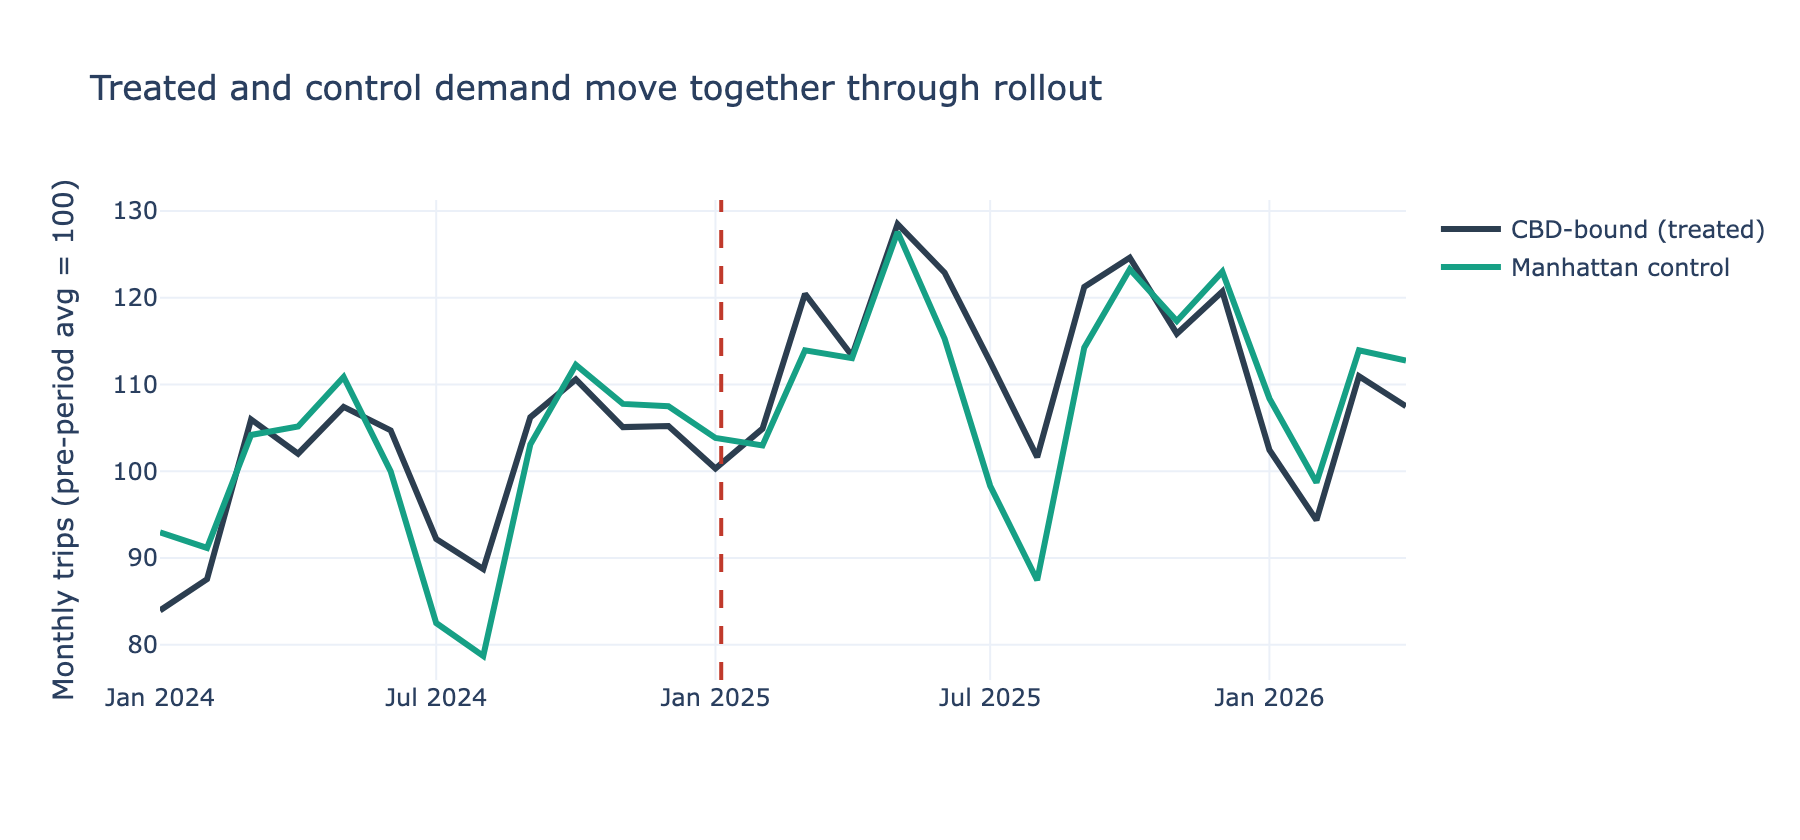

In [4]:
m = (dest.assign(ym=pd.to_datetime(dest.trip_date).dt.to_period("M").dt.to_timestamp())
        .groupby(["ym","unit"]).trips.sum().unstack())
idx = m / m.loc[m.index < TREAT].mean() * 100
fig = go.Figure()
fig.add_scatter(x=idx.index, y=idx["cbd_bound"], name="CBD-bound (treated)",
                line=dict(color="#2c3e50", width=3))
fig.add_scatter(x=idx.index, y=idx["man_control"], name="Manhattan control",
                line=dict(color="#16a085", width=3))
fig.add_vline(x=TREAT.timestamp()*1000, line=dict(color="#c0392b", dash="dash"))
fig.update_layout(title="Treated and control demand move together through rollout",
                  yaxis_title="Monthly trips (pre-period avg = 100)",
                  template="plotly_white", width=900, height=420)
Image(fig.to_image(format="png", scale=2))

## 3. Event study (dynamic DiD)

Treatment interacted with month-relative-to-rollout dummies (baseline = the month
before launch). Flat pre-period coefficients support parallel trends; flat
post-period coefficients confirm no treatment effect.

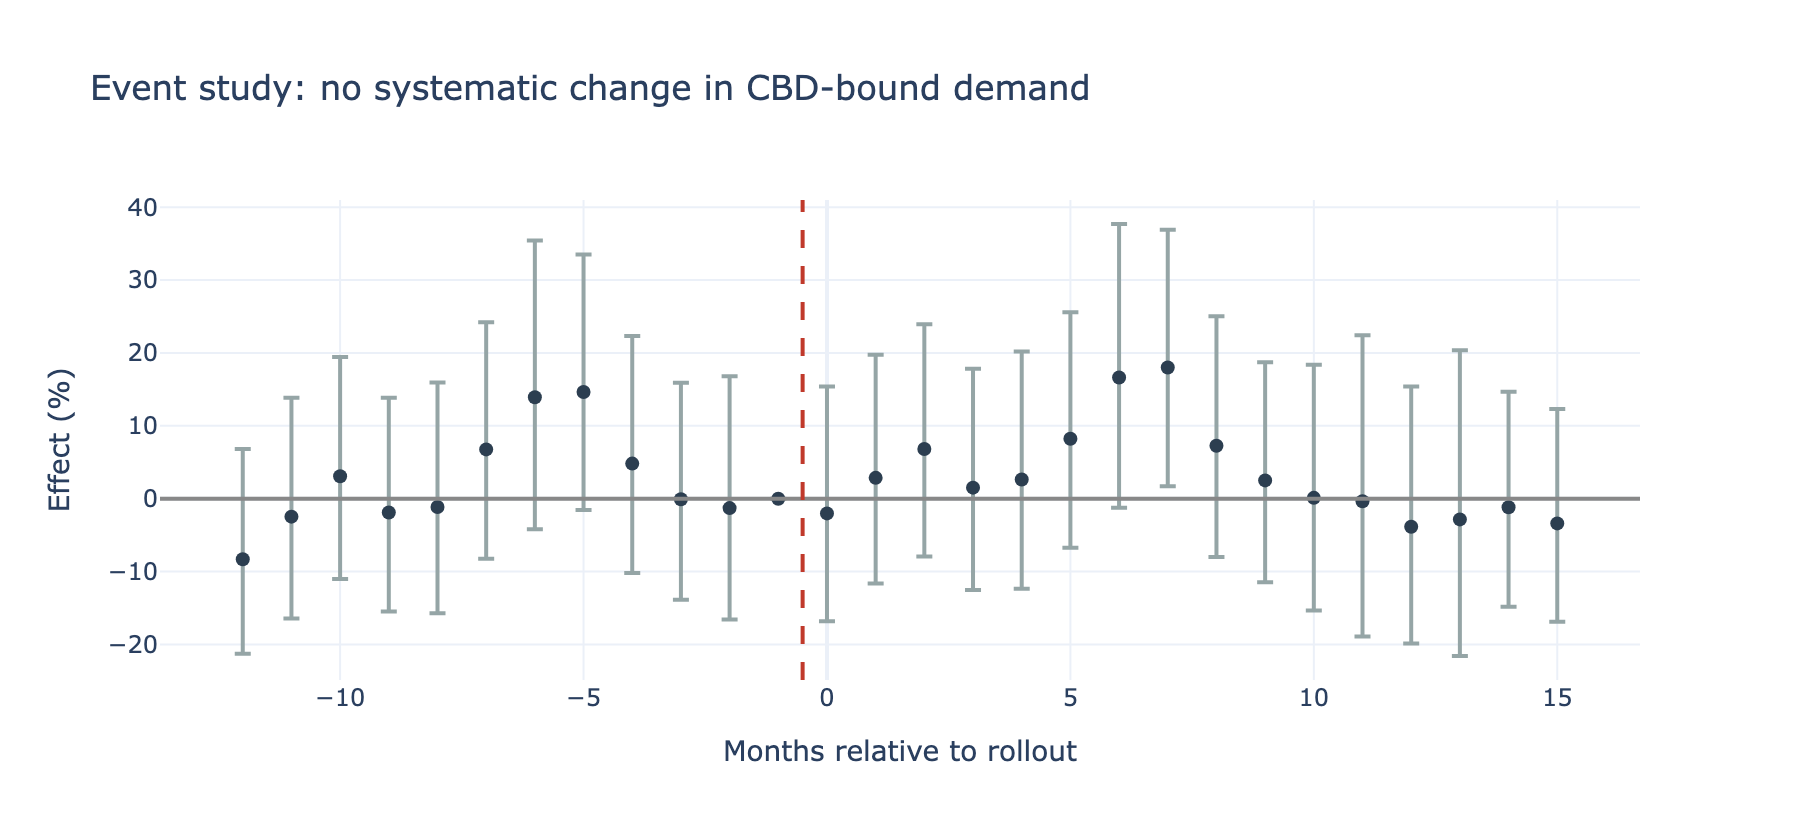

In [5]:
es = did.event_study(dest, TREAT, cfg["model"]["event_reference"])
fig = go.Figure()
fig.add_hline(y=0, line=dict(color="#888"))
fig.add_vline(x=-0.5, line=dict(color="#c0392b", dash="dash"))
fig.add_scatter(x=es.event_month, y=es.pct, mode="markers",
                marker=dict(color="#2c3e50", size=7),
                error_y=dict(type="data", symmetric=False,
                             array=es.ci_high-es.pct, arrayminus=es.pct-es.ci_low,
                             color="#95a5a6"))
fig.update_layout(title="Event study: no systematic change in CBD-bound demand",
                  xaxis_title="Months relative to rollout",
                  yaxis_title="Effect (%)", template="plotly_white",
                  width=900, height=420)
Image(fig.to_image(format="png", scale=2))

## 4. Robustness

- **Parallel trends** — pre-period treated×trend interaction is insignificant.
- **Zone fixed-effects DiD** (Manhattan, volume-weighted, clustered) agrees with
  the headline.
- **Permutation test** — the estimate is indistinguishable from randomly
  reassigning treatment across zones.
- **Placebo dates** in the pre-period produce fluctuations as large as the real
  estimate, underlining that there is no treatment signal.

In [6]:
pt = did.parallel_trends_test(dest, TREAT)
zf = did.zone_fe_did(zone, TREAT, manhattan_only=True)
rb = json.load(open(ROOT / "results" / "robustness.json"))
print(f"Parallel-trends pre-period p = {pt['pvalue']:.3f}  -> "
      f"{'parallel' if pt['passes_at_5pct'] else 'flagged'}")
print(f"Zone FE (Manhattan, weighted, clustered): {zf['pct_change']:+.1f}%  p={zf['pvalue']:.2f}")
print(f"Permutation: actual {rb['permutation_test']['actual_pct']:+.1f}%, "
      f"p = {rb['permutation_test']['perm_pvalue']:.2f}")
print("Placebo dates:", [(p['placebo_date'], f"{p['pct_change']:+.1f}%") for p in rb['placebo_dates']])

Parallel-trends pre-period p = 0.099  -> parallel
Zone FE (Manhattan, weighted, clustered): +1.1%  p=0.61
Permutation: actual +1.1%, p = 0.68
Placebo dates: [('2024-05-01', '+7.2%'), ('2024-07-01', '+6.0%'), ('2024-09-01', '-1.9%')]


## 5. Takeaway

Congestion pricing did **not** measurably reduce yellow/green-taxi trips into the
CRZ. The result is robust to the control group, the estimator, weighting, and
design-based inference. Mechanically, the toll added ~$0.75 to a CBD-bound taxi
trip — small relative to the fare — so demand barely responds. The large
congestion-pricing effects documented elsewhere are concentrated in **private
vehicle** entries, which face the full daily toll.

> Methodological note: estimating this on rideshare (HVFHV / Uber-Lyft), which
> faces a larger $1.50 per-trip CBD fee, is a natural extension — the same code
> path supports it (`config.yaml: services`).